# Glucodensity Temporal Mixture: Walkthrough

Temporal mixture models on CGM data with three representations:
1. **L² curves** — intraday glucose on a cosine basis
2. **Correlation matrices** — inter-hour correlation in Sym(24)
3. **Graph signals** — hourly glucose on a correlation-derived graph

Each is fit with time-varying cluster weights π(t) via MMD² minimisation.

In [1]:
import os, sys
import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = os.path.abspath("")
if not os.path.exists(os.path.join(project_root, "src")):
    project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

from examples.train_glucodensity_temporal import (
    CONTROL_IDS, TREATMENT_IDS,
    load_and_preprocess_cgm, compute_sliding_windows,
    build_training_representation, run_experiment,
)
from examples.train_glucodensity_correlation import (
    compute_sliding_window_correlations,
    build_temporal_coefficients,
    estimate_sigma_median_heuristic,
)
from examples.train_glucodensity_correlation_graph import (
    compute_sliding_window_hourly, compute_mean_correlation,
    threshold_to_adjacency,
)
from src import GaussianKernel, GraphLaplacianBasis, SymmetricMatrixBasis
from src.spaces import L2CosineBasis
from src.temporal_mixture import BasisLogitsTimeWeights, NeuralODETimeWeights

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
torch.manual_seed(42); np.random.seed(42)
device, dtype = torch.device("cpu"), torch.float64

K = 3        # mixture components
N_BINS = 16  # temporal bins
EPOCHS = 200
LR = 0.01

csv_path = os.path.join(project_root, "data/glucodensities/cgm_all_patients.csv")
patient_data = load_and_preprocess_cgm(csv_path, max_prop_missing=0.20, block_size=4, verbose=True)

/home/id94ebid/projects/continuous_GMM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Total days: 23760 → after rule 1 (prop_missing ≤ 0.2): 22772
  After value clipping & patient block filter: 22771 days, 98 patients
  Patients removed: 1


## 1. Data: mean hourly glucose surface

3D view of glucose across 24 hours and treatment weeks, split by group.

/home/id94ebid/projects/continuous_GMM/examples/train_glucodensity_temporal.py:181: RuntimeWarning: Mean of empty slice
  avg_curve = np.nanmean(window, axis=0)  # (288,)


  Sliding windows (size=4, stride=1):
    Total windows: 22477
    Patients contributing: 98
    Glucose range: [45.3, 396.0]
    Median patient days: 248


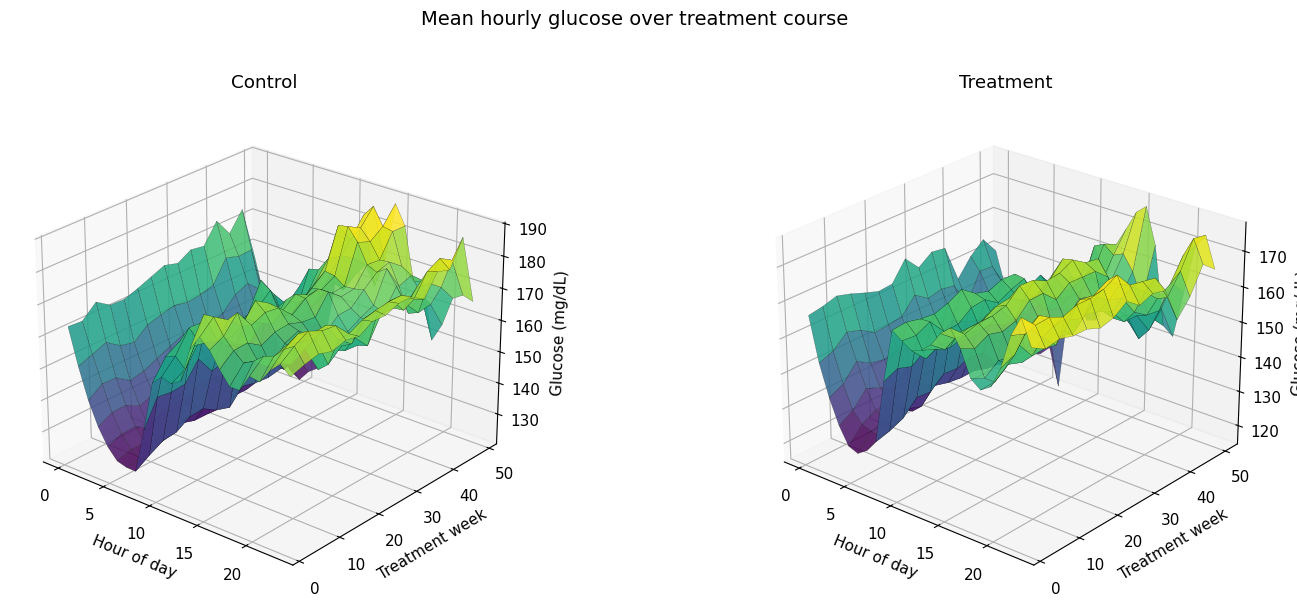

In [2]:
curves, t_indices, pids, wdays, _ = compute_sliding_windows(
    patient_data, window_size=4, stride=1, verbose=True
)
hourly_all = curves.reshape(curves.shape[0], 24, 12).mean(axis=2)
weeks = t_indices / 7.0

ctrl_mask = np.array([p in CONTROL_IDS for p in pids])
treat_mask = np.array([p in TREATMENT_IDS for p in pids])

def make_surface(mask, n_bins=15):
    w, h = weeks[mask], hourly_all[mask]
    edges = np.linspace(w.min(), w.max() + 0.01, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, np.array([
        h[(w >= edges[i]) & (w < edges[i + 1])].mean(0) for i in range(n_bins)
    ])

fig = plt.figure(figsize=(16, 6))
hours = np.arange(24)
for i, (mask, title) in enumerate([(ctrl_mask, "Control"), (treat_mask, "Treatment")]):
    centers, surf = make_surface(mask)
    H, W = np.meshgrid(hours, centers)
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.plot_surface(H, W, surf, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.15)
    ax.set(xlabel="Hour of day", ylabel="Treatment week", zlabel="Glucose (mg/dL)")
    ax.set_title(title)
    ax.view_init(elev=25, azim=-50)
plt.suptitle("Mean hourly glucose over treatment course", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
centers, surf = make_surface(ctrl_mask)

In [44]:
surf_ctrl.shape

(15, 24)

In [45]:
surf_treat.shape

(15, 24)

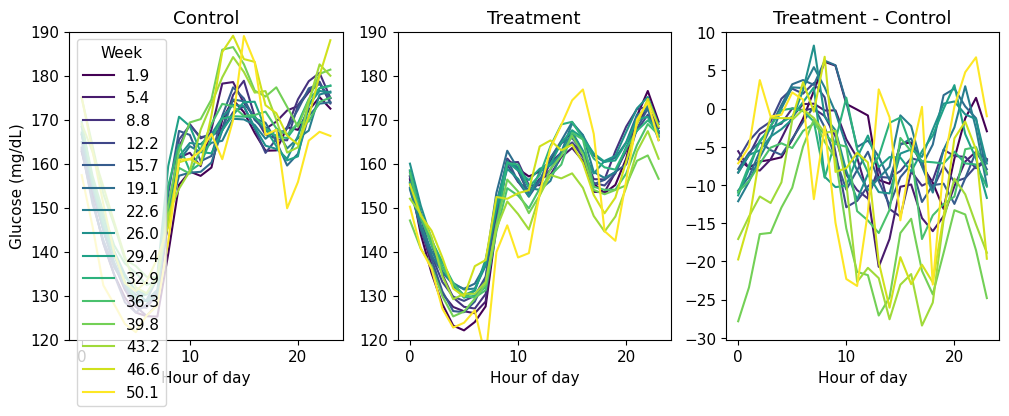

In [50]:
# 1. Choose your colormap
cmap = plt.get_cmap('viridis') 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

centers, surf_ctrl = make_surface(ctrl_mask)
centers, surf_treat = make_surface(treat_mask)

# 2. Loop through each column and plot
for i in range(surf_ctrl.shape[0]):
    # Use i / (num_lines - 1) to get a value between 0 and 1 for the cmap
    
    color = cmap(i / max(1, surf_ctrl.shape[0] - 1))
    axes[0].plot(hours, surf_ctrl[i, :], color=color, label=f'{centers[i]:.1f}')

    axes[1].plot(hours, surf_treat[i, :], color=color)

    axes[0].set_ylim(120, 190)
    axes[1].set_ylim(120, 190)

    axes[0].set_xlabel('Hour of day')
    axes[0].set_ylabel('Glucose (mg/dL)')
    axes[0].set_title('Control')
    axes[1].set_xlabel('Hour of day')
    axes[1].set_title('Treatment')
    axes[0].legend(title='Week', loc='upper left')

    axes[2].set_xlabel('Hour of day')
    axes[2].set_title('Treatment - Control')
    axes[2].plot(hours, surf_treat[i, :]-surf_ctrl[i, :], color=color, label=f'{centers[i]:.1f}')

In [16]:
hourly_all.shape

(22477, 24)

## 2. Temporal mixture on L² curves

Intraday glucose profiles projected onto a cosine basis.
We compare **NeuralODE** vs **Cosine basis** for the time-varying weights π(t).

  Temporal binning: 16 requested, 16 non-empty
  Day range: [1.5, 362.5]
  Bin sizes (valid samples): min=80, max=2223, median=1610
  Padded to n_max=2223
  X_time_raw shape: (16, 2223, 288)
Epoch   25/200: MMD²(avg_t) = 0.055802
Epoch   50/200: MMD²(avg_t) = 0.030479
Epoch   75/200: MMD²(avg_t) = 0.016508
Epoch  100/200: MMD²(avg_t) = 0.009245
Epoch  125/200: MMD²(avg_t) = 0.006148
Epoch  150/200: MMD²(avg_t) = 0.005096
Epoch  175/200: MMD²(avg_t) = 0.004702
Epoch  200/200: MMD²(avg_t) = 0.004504
NeuralODE final MMD²(avg_t): 0.004504
NeuralODE mean pi over t: [0.14633346 0.55994008 0.29372646]
Epoch   25/200: MMD²(avg_t) = 0.067050
Epoch   50/200: MMD²(avg_t) = 0.030449
Epoch   75/200: MMD²(avg_t) = 0.015233
Epoch  100/200: MMD²(avg_t) = 0.009564
Epoch  125/200: MMD²(avg_t) = 0.007335
Epoch  150/200: MMD²(avg_t) = 0.006182
Epoch  175/200: MMD²(avg_t) = 0.005480
Epoch  200/200: MMD²(avg_t) = 0.005038
CosineBasis final MMD²(avg_t): 0.005038
CosineBasis mean pi over t: [0.7084786  0.1888

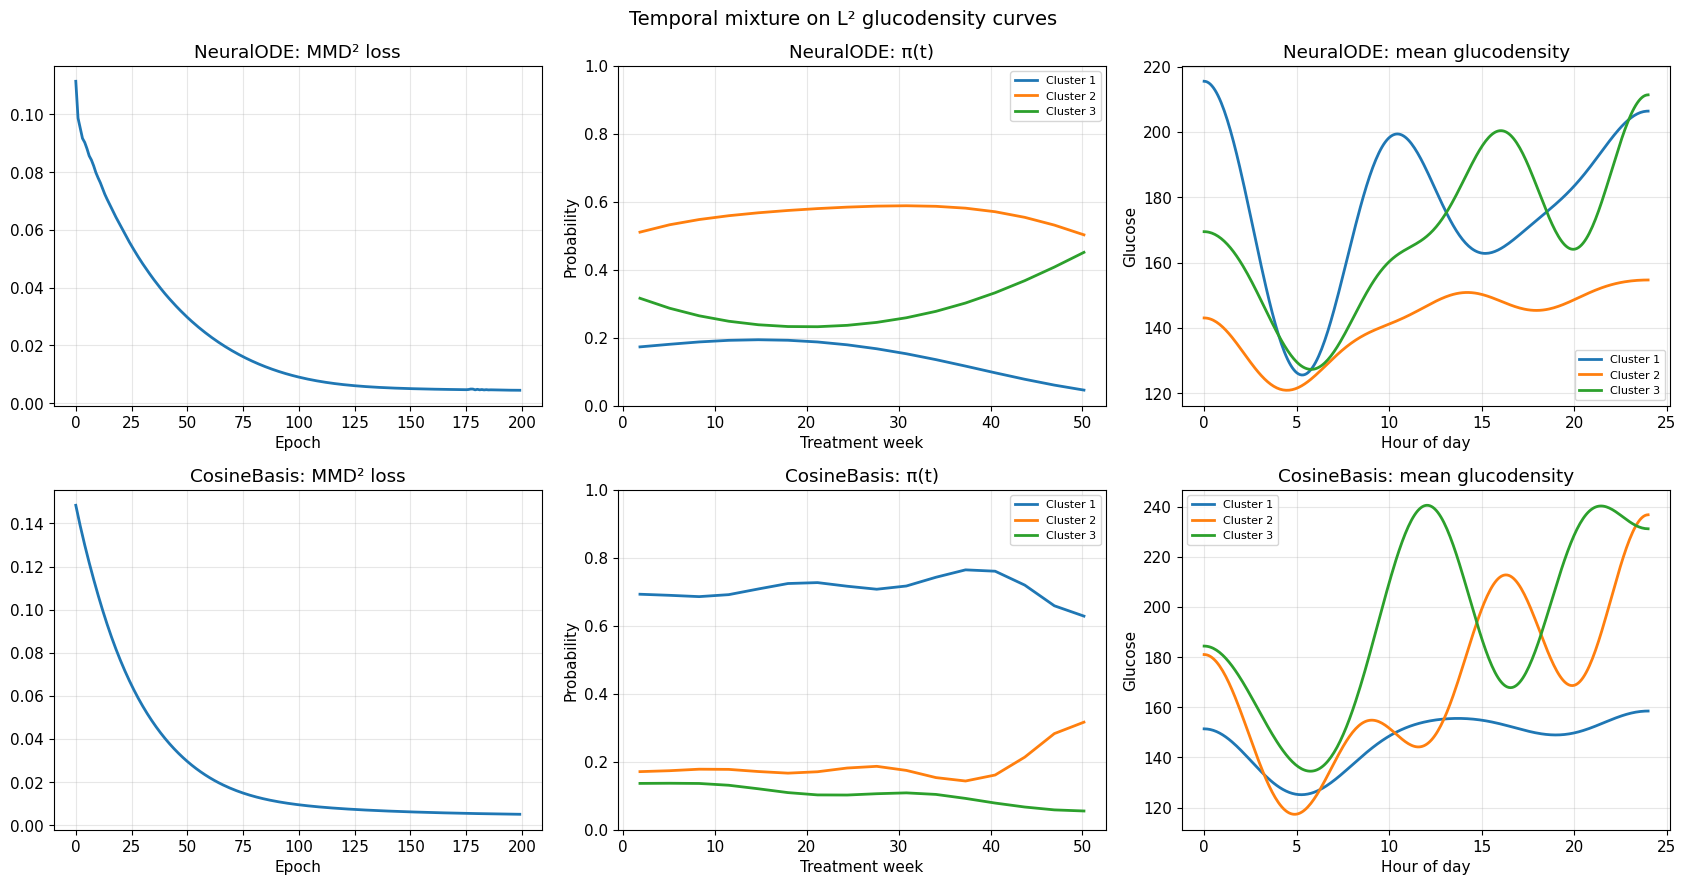

In [3]:
rep = build_training_representation(
    curves, t_indices, n_time_bins=N_BINS, r_s=8, device=device, dtype=dtype, verbose=True
)
X_time, t_grid, mask = rep["X_time"], rep["t_grid"], rep["mask"]
kernel = GaussianKernel(sigma=max(1e-8, rep["sigma_auto"]))

def train_and_extract(name, tw_model):
    model, history, pi_t = run_experiment(
        name, tw_model, X_time, kernel, K, rep["coeff_dim"],
        EPOCHS, LR, device, dtype, mask, verbose=True,
    )
    with torch.no_grad():
        means = model.mean.cpu() * rep["coeff_std"].cpu() + rep["coeff_mean"].cpu()
        recon = rep["space_basis"].reconstruct(means).squeeze(-1).numpy()
    return history, pi_t.cpu().numpy(), recon

# NeuralODE
ode_h, ode_pi, ode_m = train_and_extract(
    "NeuralODE", NeuralODETimeWeights(t_grid, K, hidden_dim=64, device=device, dtype=dtype)
)
# Cosine basis
phi = L2CosineBasis(T=1.0, R=6, grid_size=rep["L_t"], d=1, device=device, dtype=dtype)
bas_h, bas_pi, bas_m = train_and_extract(
    "CosineBasis", BasisLogitsTimeWeights(phi.Phi, K, device=device, dtype=dtype)
)

# --- Plot both models ---
t_days = t_grid.cpu().numpy() * (rep["t_max_days"] - rep["t_min_days"]) + rep["t_min_days"]
t_weeks = t_days / 7.0
slot_x = np.linspace(0, 24, ode_m.shape[1])

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for row, (h, pi, m, name) in enumerate([
    (ode_h, ode_pi, ode_m, "NeuralODE"),
    (bas_h, bas_pi, bas_m, "CosineBasis"),
]):
    axes[row, 0].plot(h, lw=2)
    axes[row, 0].set(title=f"{name}: MMD² loss", xlabel="Epoch")
    axes[row, 0].grid(alpha=0.3)

    for k in range(K):
        axes[row, 1].plot(t_weeks, pi[:, k], lw=2, label=f"Cluster {k + 1}")
    axes[row, 1].set(title=f"{name}: π(t)", xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(alpha=0.3)

    for k in range(K):
        axes[row, 2].plot(slot_x, m[k], lw=2, label=f"Cluster {k + 1}")
    axes[row, 2].set(title=f"{name}: mean glucodensity", xlabel="Hour of day", ylabel="Glucose")
    axes[row, 2].legend(fontsize=8)
    axes[row, 2].grid(alpha=0.3)

plt.suptitle("Temporal mixture on L² glucodensity curves", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Correlation matrix model

Sliding-window 24×24 inter-hour correlation matrices, embedded in Sym(24) via scaled vech.

  Sliding-window correlations (size=14, stride=1):
    Total windows: 21497
    Patients contributing: 98
  Temporal binning: 16 requested, 16 non-empty
  Day range: [6.5, 357.5]
  Bin sizes: min=73, max=2098, median=1515
  Padded to n_max=2098, coeff_dim=300
Epoch   37/300: MMD²(avg_t) = 0.049091
Epoch   74/300: MMD²(avg_t) = 0.021793
Epoch  111/300: MMD²(avg_t) = 0.012367
Epoch  148/300: MMD²(avg_t) = 0.009227
Epoch  185/300: MMD²(avg_t) = 0.007845
Epoch  222/300: MMD²(avg_t) = 0.007176
Epoch  259/300: MMD²(avg_t) = 0.006853
Epoch  296/300: MMD²(avg_t) = 0.006402
CorrODE final MMD²(avg_t): 0.007873
CorrODE mean pi over t: [0.26925161 0.41756833 0.31318006]


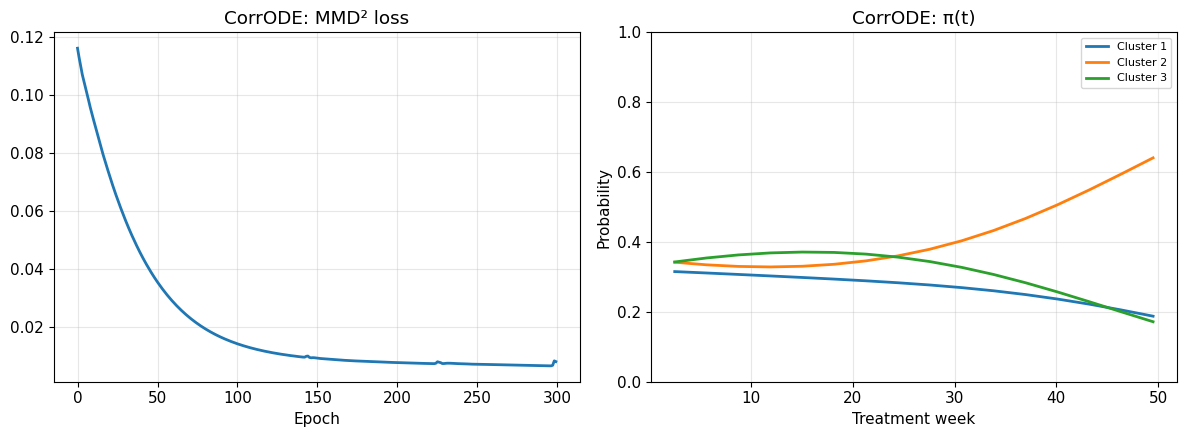

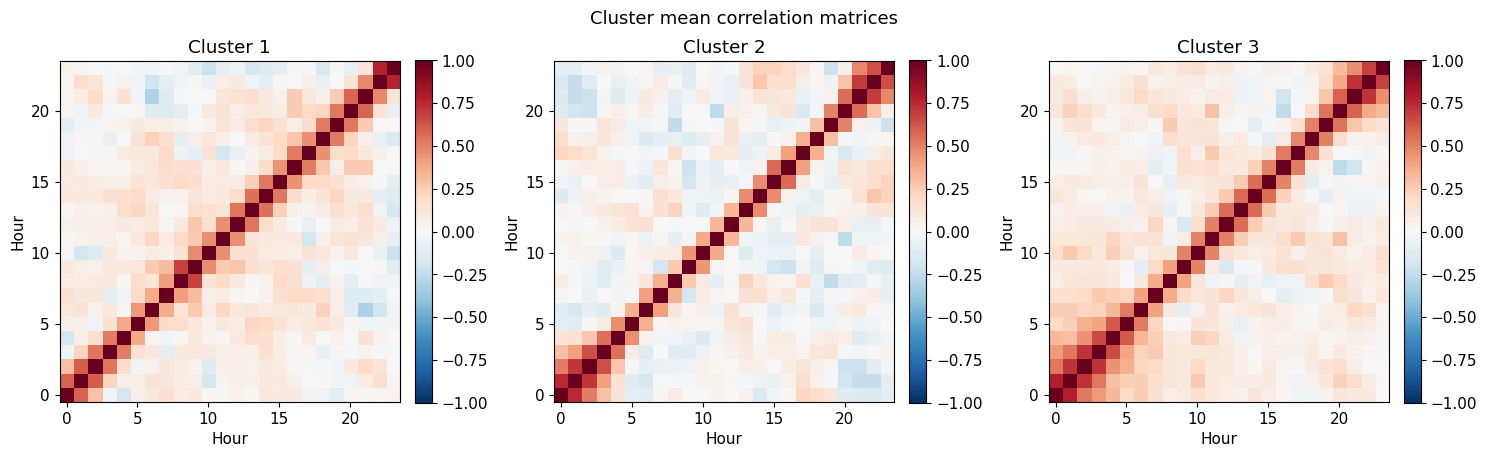

In [6]:
corr_mats, corr_t, corr_pids, corr_wd, _ = compute_sliding_window_correlations(
    patient_data, window_size=14, stride=1, shrinkage=0.1, verbose=True
)
sym_basis = SymmetricMatrixBasis(n=24, device=device, dtype=dtype)
corr_coeffs = sym_basis.project(
    torch.tensor(corr_mats, device=device, dtype=dtype)
).detach().cpu().numpy()

corr_rep = build_temporal_coefficients(corr_coeffs, corr_t, N_BINS, device, dtype)
sigma_c = estimate_sigma_median_heuristic(corr_rep["X_time"], corr_rep["mask"])

model_c, hist_c, pi_c = run_experiment(
    "CorrODE",
    NeuralODETimeWeights(corr_rep["t_grid"], K, hidden_dim=64, device=device, dtype=dtype),
    corr_rep["X_time"], GaussianKernel(sigma=max(1e-8, sigma_c)),
    K, corr_rep["coeff_dim"], EPOCHS+100, LR, device, dtype, corr_rep["mask"], verbose=True,
)

with torch.no_grad():
    recon_corr = sym_basis.reconstruct(
        model_c.mean.cpu() * corr_rep["coeff_std"].cpu() + corr_rep["coeff_mean"].cpu()
    ).numpy()

t_weeks_c = (
    corr_rep["t_grid"].cpu().numpy()
    * (corr_rep["t_max_days"] - corr_rep["t_min_days"]) + corr_rep["t_min_days"]
) / 7.0

# Training curve + π(t)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(hist_c, lw=2)
ax1.set(title="CorrODE: MMD² loss", xlabel="Epoch")
ax1.grid(alpha=0.3)
for k in range(K):
    ax2.plot(t_weeks_c, pi_c.cpu().numpy()[:, k], lw=2, label=f"Cluster {k + 1}")
ax2.set(title="CorrODE: π(t)", xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster mean correlation heatmaps
fig, axes = plt.subplots(1, K, figsize=(5 * K, 4.5))
for k in range(K):
    im = axes[k].imshow(recon_corr[k], cmap="RdBu_r", vmin=-1, vmax=1, origin="lower")
    axes[k].set(title=f"Cluster {k + 1}", xlabel="Hour", ylabel="Hour")
    fig.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)
plt.suptitle("Cluster mean correlation matrices", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Graph Laplacian model

A graph over 24 hours is built from inter-hour correlations.
Each window's hourly glucose is a graph signal projected onto the Laplacian eigenbasis.

/home/id94ebid/projects/continuous_GMM/examples/train_glucodensity_correlation_graph.py:71: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=2)


  Mean correlation computed from 21497 windows
  Edges (|corr| > 0.5): 12
  Sliding windows (size=7, stride=1):
    Total windows: 22183
    Patients contributing: 98
    Glucose range: [56.1, 340.4]
  Temporal binning: 16 requested, 16 non-empty
  Day range: [3.0, 361.0]
  Bin sizes: min=80, max=2214, median=1568
  Padded to n_max=2214, coeff_dim=15
Epoch   25/200: MMD²(avg_t) = 0.040401
Epoch   50/200: MMD²(avg_t) = 0.018125
Epoch   75/200: MMD²(avg_t) = 0.010037
Epoch  100/200: MMD²(avg_t) = 0.007458
Epoch  125/200: MMD²(avg_t) = 0.006642
Epoch  150/200: MMD²(avg_t) = 0.006325
Epoch  175/200: MMD²(avg_t) = 0.006155
Epoch  200/200: MMD²(avg_t) = 0.006032
GraphODE final MMD²(avg_t): 0.006032
GraphODE mean pi over t: [0.44942749 0.13351774 0.41705477]


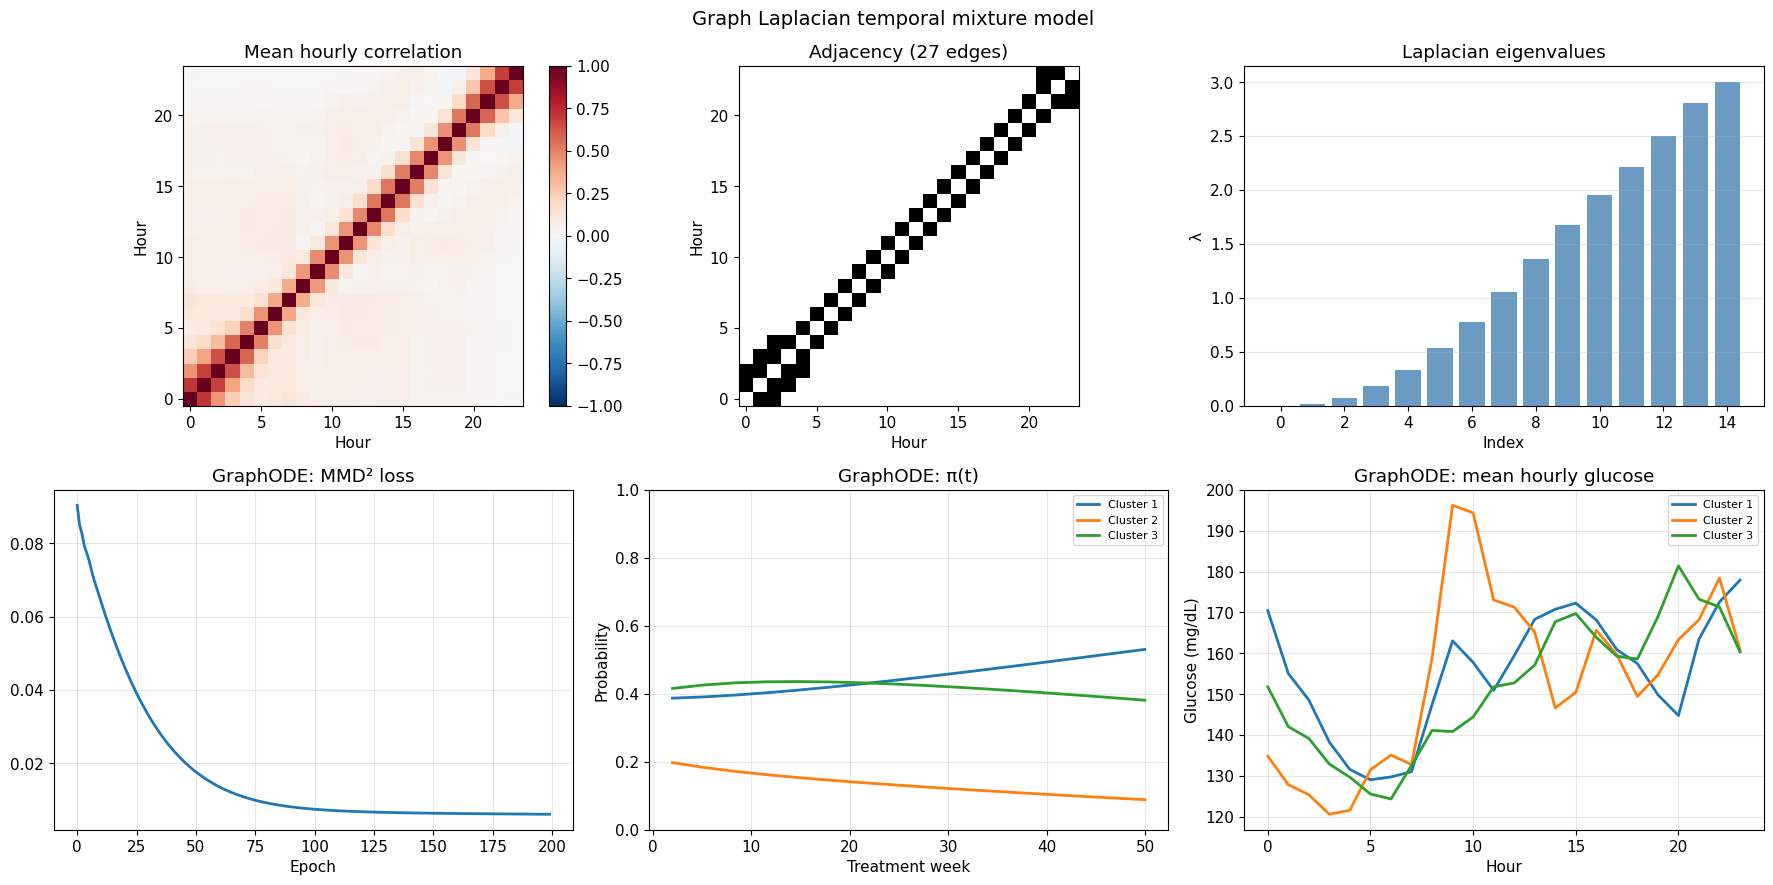

In [5]:
mean_corr = compute_mean_correlation(
    patient_data, window_size=14, stride=1, shrinkage=0.1, verbose=True
)
adj = threshold_to_adjacency(mean_corr, threshold=0.3)
graph_basis = GraphLaplacianBasis.from_adjacency(
    adjacency=torch.tensor(adj, device=device, dtype=dtype),
    alpha=0.1, num_eigenvectors=15, device=device, dtype=dtype,
)

hourly_sig, g_t, g_pids, g_wd, _ = compute_sliding_window_hourly(
    patient_data, window_size=7, stride=1, verbose=True
)
g_coeffs = graph_basis.project(
    torch.tensor(hourly_sig, device=device, dtype=dtype)
).detach().cpu().numpy()
g_rep = build_temporal_coefficients(g_coeffs, g_t, N_BINS, device, dtype)
sigma_g = estimate_sigma_median_heuristic(g_rep["X_time"], g_rep["mask"])

model_g, hist_g, pi_g = run_experiment(
    "GraphODE",
    NeuralODETimeWeights(g_rep["t_grid"], K, hidden_dim=64, device=device, dtype=dtype),
    g_rep["X_time"], GaussianKernel(sigma=max(1e-8, sigma_g)),
    K, g_rep["coeff_dim"], EPOCHS, LR, device, dtype, g_rep["mask"], verbose=True,
)

with torch.no_grad():
    recon_hourly = graph_basis.reconstruct(
        model_g.mean.cpu() * g_rep["coeff_std"].cpu() + g_rep["coeff_mean"].cpu()
    ).numpy()

t_weeks_g = (
    g_rep["t_grid"].cpu().numpy()
    * (g_rep["t_max_days"] - g_rep["t_min_days"]) + g_rep["t_min_days"]
) / 7.0

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Row 1: graph structure
im0 = axes[0, 0].imshow(mean_corr, cmap="RdBu_r", vmin=-1, vmax=1, origin="lower")
axes[0, 0].set(title="Mean hourly correlation", xlabel="Hour", ylabel="Hour")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

n_edges = int(adj.sum()) // 2
axes[0, 1].imshow(adj, cmap="Greys", origin="lower")
axes[0, 1].set(title=f"Adjacency ({n_edges} edges)", xlabel="Hour", ylabel="Hour")

eigs = graph_basis.eigenvalues.detach().cpu().numpy()
axes[0, 2].bar(range(len(eigs)), eigs, color="steelblue", alpha=0.8)
axes[0, 2].set(title="Laplacian eigenvalues", xlabel="Index", ylabel="λ")
axes[0, 2].grid(alpha=0.3, axis="y")

# Row 2: model results
axes[1, 0].plot(hist_g, lw=2)
axes[1, 0].set(title="GraphODE: MMD² loss", xlabel="Epoch")
axes[1, 0].grid(alpha=0.3)
for k in range(K):
    axes[1, 1].plot(t_weeks_g, pi_g.cpu().numpy()[:, k], lw=2, label=f"Cluster {k + 1}")
axes[1, 1].set(title="GraphODE: π(t)", xlabel="Treatment week", ylabel="Probability", ylim=(0, 1))
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)
for k in range(K):
    axes[1, 2].plot(np.arange(24), recon_hourly[k], lw=2, label=f"Cluster {k + 1}")
axes[1, 2].set(title="GraphODE: mean hourly glucose", xlabel="Hour", ylabel="Glucose (mg/dL)")
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(alpha=0.3)

plt.suptitle("Graph Laplacian temporal mixture model", fontsize=14)
plt.tight_layout()
plt.show()